In [1]:
from backend_langgraph.search import search_and_crawl
from backend_langgraph.db import get_vectorstore, get_relevant_context, add_to_vector_database, has_relevant_data
from backend_langgraph.llm import call_llm
from backend_langgraph.util import few_shot_needs_web_search, needs_web_search

In [2]:
from langgraph.graph import START, END, StateGraph
from typing import List, Optional, Tuple
from typing_extensions import TypedDict

class AgentState(TypedDict):
    prompt: str
    vectorstore: Optional[Tuple]
    is_generic: Optional[bool]
    needs_web: Optional[bool]
    context_exists: Optional[bool]
    context: Optional[str]
    documents: Optional[List[str]]
    response: Optional[str]
    llm: Optional[object]

In [3]:
def initialize(state: AgentState) -> AgentState:
    print("Initializing agent state...")
    state['vectorstore'] = get_vectorstore()
    #can also call the LLM thread
    return state

def check_prompt(state: AgentState) -> AgentState:
    print(f"Prompt received", {state['prompt']})
    return state

def check_generic(state: AgentState) -> AgentState:
    state['is_generic'] = few_shot_needs_web_search(state['prompt'])
    print(f"Is the prompt generic:", {state['is_generic']})
    return state

def check_needs_web_search(state: AgentState) -> AgentState:
    state['needs_web'] = few_shot_needs_web_search(state['prompt'])
    print(f"Does the prompt needs to be web searched:", {state['needs_web']})
    return state

def check_context_in_db(state: AgentState) -> AgentState:
    state['context_exists'] = has_relevant_data(state['vectorstore'], state['prompt'])
    print(f"Context exists in DB:", {state['context_exists']})
    return state

def retrieve_context(state: AgentState) -> AgentState:
    context_list = get_relevant_context(state['vectorstore'], state['prompt'])
    state['context'] = "\n\n".join(context_list) if context_list else None
    print(f"Retrieved context:", {state['context']})
    return state

async def perform_web_search(state: AgentState) -> AgentState:
    state['documents'] = await search_and_crawl(state['prompt'])
    print(f"Web search documents:", state['documents'])
    return state

def add_documents_to_db(state: AgentState) -> AgentState:
    add_to_vector_database(state['vectorstore'], state['documents'])
    print("Documents added to DB")
    return state

def call_llm_state(state: AgentState) -> AgentState:
    state['response'] = call_llm(prompt=state['prompt'], context=state.get('context'))
    print(f"LLM Response:", {state['response']})
    return state

def finish(state: AgentState) -> AgentState:
    print("Final state reached.")
    return state


In [4]:
workflow = StateGraph(AgentState)
# Add nodes
workflow.add_node("get_vector_db", initialize)
workflow.add_node("check_prompt", check_prompt)
workflow.add_node("check_generic_query", check_generic)
workflow.add_node("check_database", check_context_in_db)
workflow.add_node("web_search_needed", check_needs_web_search)
workflow.add_node("perform_web_search", perform_web_search)
workflow.add_node("add_documents_to_db", add_documents_to_db)
workflow.add_node("retrieve_context", retrieve_context)
workflow.add_node("call_llm", call_llm_state)

# Define edges
workflow.add_edge(START, "check_prompt")
workflow.add_edge("check_prompt","get_vector_db")
workflow.add_edge("get_vector_db", "check_generic_query")
workflow.add_conditional_edges(
    "check_generic_query", 
    lambda state: state["is_generic"],
    {True: "call_llm", False: "check_database"}
)
workflow.add_conditional_edges(
    "check_database",
    lambda state: state["context_exists"],
    {True: "retrieve_context", False: "web_search_needed"}
)
workflow.add_conditional_edges(
    "web_search_needed",
    lambda state: state["needs_web"],
    {True: "call_llm", False: "perform_web_search"}
)
workflow.add_edge("perform_web_search", "add_documents_to_db")
workflow.add_edge("perform_web_search", "call_llm")
workflow.add_edge("retrieve_context", "call_llm")
workflow.add_edge("call_llm", END)

# Compile the workflow
app = workflow.compile()


In [5]:
state = AgentState(prompt="Who won the latest ICC cricket tournament hosted by pakistan recently in 2025?")

In [6]:
res =  await app.ainvoke(state)

Prompt received {'Who won the latest ICC cricket tournament hosted by pakistan recently in 2025?'}
Initializing agent state...


Is the prompt generic: {False}
Context exists in DB: {True}
Retrieved context: {". It took more than 15 years after the attack for the country to host a major tournament again. Pakistan for a chance to host International Cricket Council events taking place between 2024 and 2031. It was allocated the Champions Trophy in 2021. What paved the way was the ICC lending support in 2017 for a group of international all-stars as part of a Cricket World XI tour, he says\n\nA dominant performance from Pakistan and a series-clinching victory 🙌📝 : — ICC (@ICC) It was Pakistan's fifth bilateral ODI series victory on the trot - following previous series triumphs over Australia and Zimbabwe in recent months - and they also become the first Asian side to have won a trio of ODI series in South Africa having also tasted success in the country in 2021 and 2013\n\n. Host: England Teams: Eight Final: India vs Pakistan Winner: Pakistan – by 180 runs Player of the tournament: Hasan Ali (Pakistan) After termin

In [ ]:
res

In [22]:
state.keys()

dict_keys(['prompt'])

In [23]:
state.get("vectorstore")

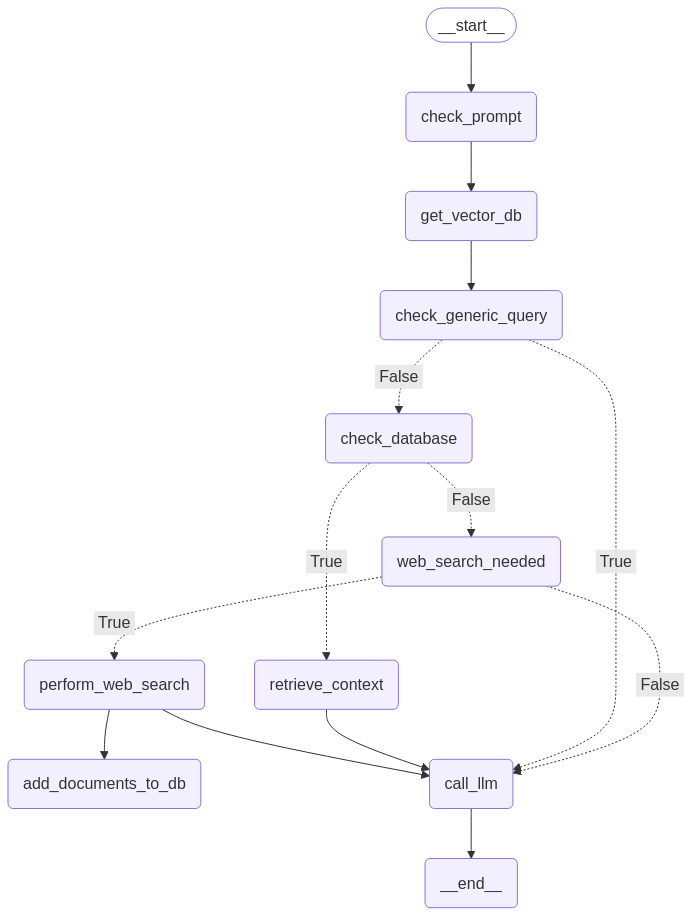

In [70]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except:
    pass